<a href="https://colab.research.google.com/github/AyaAbdElNaem/AI_Tools/blob/main/Lab4_CNN_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CNN (Convolutional Neural Networks):

---

**What you will learn in this notebook:**

| # | Topic | What You'll See |
|---|-------|-----------------|
| 1 | What a CNN is | A plain-English explanation with zero jargon |
| 2 | How images become numbers | Pixels → NumPy arrays |
| 3 | What each layer does | Visual output of EVERY single layer |
| 4 | Convolution (Conv2D) | How filters scan an image to detect patterns |
| 5 | Activation (ReLU) | How the network decides "this matters" |
| 6 | Pooling (MaxPool2D) | How the network shrinks information smartly |
| 7 | Flatten + Dense | How 2D feature maps become a final decision |
| 8 | Training | Watch the model learn in real-time |
| 9 | Evaluation | Did it actually learn? Proof with numbers |

**Task:** Binary Classification — **Cat vs Dog** images from the CIFAR-10 dataset.


---


##  Section 1: The Big Picture — What is a CNN?

A **Convolutional Neural Network (CNN)** is a type of neural network specifically designed to work with **images**.

Think of it like an assembly line in a factory:

```
THE CNN ASSEMBLY LINE
                        
   Raw Image
       │
       ▼
  ┌─────────────┐
  │  Conv2D     │ ◄── Worker 1: "I look for edges, corners, colors"
  │  (Filter)   │
  └──────┬──────┘
         ▼
  ┌─────────────┐
  │   ReLU      │ ◄── Worker 2: "I throw away the noise, keep the signal"
  │ (Activation)│
  └──────┬──────┘
         ▼
  ┌─────────────┐
  │  MaxPool2D  │ ◄── Worker 3: "I shrink it down, keep only the best parts"
  │  (Pooling)  │
  └──────┬──────┘
         ▼
     ... repeat ...
         ▼
  ┌─────────────┐
  │   Flatten   │ ◄── Worker 4: "I unroll the 2D map into a single line"
  └──────┬──────┘
         ▼
  ┌─────────────┐
  │    Dense    │ ◄── Worker 5: "I make the final decision: Cat or Dog?"
  └─────────────┘
         │
         ▼
 Cat (92%) /  Dog (8%)
```


---


##  Section 2: Setup — Import Libraries



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

##  Section 3: Load the Dataset — Cats vs Dogs from CIFAR-10

**CIFAR-10** is a famous dataset with 60,000 tiny (32×32 pixel) color images in 10 classes.

We only need **2 classes**:
- Class **3** = Cat
- Class **5** = Dog   



In [15]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()

cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

CAT_LABEL = 3
DOG_LABEL = 5

train_mask = (y_train_full.flatten() == CAT_LABEL) | (y_train_full.flatten() == DOG_LABEL)
x_train = x_train_full[train_mask]
y_train = y_train_full[train_mask]

test_mask = (y_test_full.flatten() == CAT_LABEL) | (y_test_full.flatten() == DOG_LABEL)
x_test = x_test_full[test_mask]
y_test = y_test_full[test_mask]

y_train = (y_train == DOG_LABEL).astype(np.float32).flatten()
y_test  = (y_test == DOG_LABEL).astype(np.float32).flatten()

print(f"Training images: {x_train.shape[0]}")
print(f"Test images:     {x_test.shape[0]}")
print(f"Image shape:     {x_train[0].shape}  (height=32, width=32, channels=3 for RGB)")
print(f"Labels:          0 = Cat ,  1 = Dog ")
print(f"Train cats: {np.sum(y_train==0):.0f} | Train dogs: {np.sum(y_train==1):.0f}")


Training images: 10000
Test images:     2000
Image shape:     (32, 32, 3)  (height=32, width=32, channels=3 for RGB)
Labels:          0 = Cat ,  1 = Dog 
Train cats: 5000 | Train dogs: 5000


##  Section 4: What Do These Images Actually Look Like?

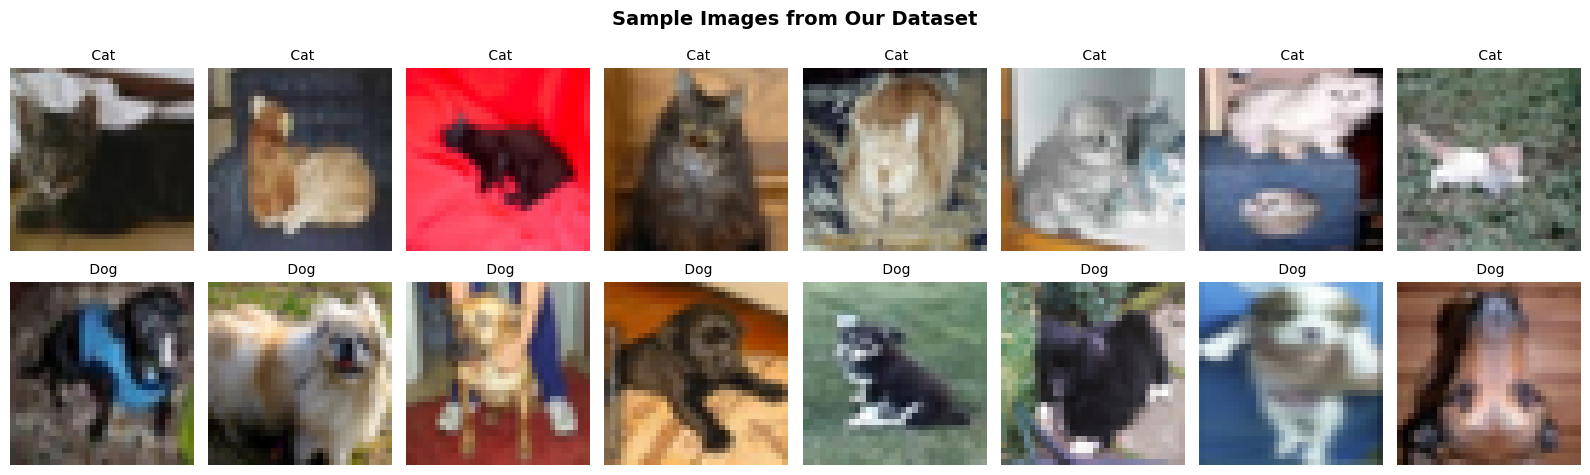

In [16]:
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Sample Images from Our Dataset", fontsize=14, fontweight='bold')

cat_indices = np.where(y_train == 0)[0][:8]
for i, idx in enumerate(cat_indices):
    axes[0, i].imshow(x_train[idx])
    axes[0, i].set_title(" Cat", fontsize=10)
    axes[0, i].axis('off')

dog_indices = np.where(y_train == 1)[0][:8]
for i, idx in enumerate(dog_indices):
    axes[1, i].imshow(x_train[idx])
    axes[1, i].set_title(" Dog", fontsize=10)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

##  Section 5: Preprocess — Normalize the Pixels

Neural networks work **much better** when numbers are small (between 0 and 1) instead of large (0 to 255).

Why? Because large numbers make the math unstable during training.

**The fix is simple:** divide every pixel by 255.


In [17]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print(f"Before normalization: pixels ranged from 0 to 255")
print(f"After normalization:  pixels range from {x_train.min()} to {1}")

Before normalization: pixels ranged from 0 to 255
After normalization:  pixels range from 0.0 to 1


##  Section 6: Build the CNN — Layer by Layer

```
INPUT (32×32×3)
    │
    ├─► Conv2D(8 filters, 3×3)   → output: 30×30×8
    ├─► ReLU activation           → output: 30×30×8
    ├─► MaxPooling2D(2×2)         → output: 15×15×8
    │
    ├─► Conv2D(16 filters, 3×3)  → output: 13×13×16
    ├─► ReLU activation           → output: 13×13×16
    ├─► MaxPooling2D(2×2)         → output: 6×6×16
    │
    ├─► Flatten                   → output: 576
    ├─► Dense(32, relu)           → output: 32
    ├─► Dense(1, sigmoid)         → output: 1  (probability of Dog)
```
###  Layer 1: Conv2D — The Feature Detector

A **convolution** is just a small window (called a **filter** or **kernel**) that slides across the image looking for patterns.

```
   The 3×3 filter slides across the image:
   
   Image (5×5 shown):          Filter (3×3):        Output:
   ┌───┬───┬───┬───┬───┐      ┌───┬───┬───┐       Each position = sum of (image patch × filter)
   │ 1 │ 0 │ 1 │ 0 │ 1 │      │ 1 │ 0 │ 1 │       
   ├───┼───┼───┼───┼───┤      ├───┼───┼───┤       
   │ 0 │ 1 │ 0 │ 1 │ 0 │      │ 0 │ 1 │ 0 │       
   ├───┼───┼───┼───┼───┤      ├───┼───┼───┤       → Produces a
   │ 1 │ 0 │ 1 │ 0 │ 1 │      │ 1 │ 0 │ 1 │         "feature map"
   ├───┼───┼───┼───┼───┤      └───┴───┴───┘       
   │ 0 │ 1 │ 0 │ 1 │ 0 │                          
   ├───┼───┼───┼───┼───┤      
   │ 1 │ 0 │ 1 │ 0 │ 1 │      8 filters = 8 different feature maps
   └───┴───┴───┴───┴───┘      (each filter looks for a different pattern)
```

###  Layer 2: ReLU Activation — The Gatekeeper

ReLU is simple: **if the number is negative, replace it with 0. Otherwise, keep it.**

```
   ReLU( 3.5) =  3.5  ✅ Keep it
   ReLU(-2.0) =  0.0  ❌ Kill it
   ReLU( 0.1) =  0.1  ✅ Keep it
   ReLU(-99 ) =  0.0  ❌ Kill it
```

Why? Because negative values usually mean "this pattern was NOT found here." ReLU cleans up the noise.

###  Layer 3: MaxPooling2D — The Shrinker

MaxPooling takes a 2×2 window and keeps **only the maximum value**:

```
   ┌────┬────┐          
   │ 1  │ 3  │          
   ├────┼────┤  ──►  max = 4
   │ 4  │ 2  │          
   └────┴────┘          
   
   This shrinks the image to HALF its size.
   32×32 → 16×16 (approximately, depending on exact math)
```

Why? Two reasons:
1. **Reduces computation** — fewer numbers to process
2. **Makes features position-independent** — "there's an edge SOMEWHERE in this area"

---


In [18]:
model = keras.Sequential([
    layers.Conv2D(filters=8, kernel_size=(3,3), activation='relu',input_shape=(32, 32, 3), name='conv2d_block1'),
    layers.MaxPooling2D(pool_size=(2,2), name='maxpool_block1'),

    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu',name='conv2d_block2'),
    layers.MaxPooling2D(pool_size=(2,2), name='maxpool_block2'),

    layers.Flatten(name='flatten'),
    layers.Dense(32, activation='relu', name='dense_hidden'),
    layers.Dense(1, activation='sigmoid', name='output_prediction'),
], name='CatVsDog_CNN')

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CatVsDog_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_block1 (Conv2D)          │ (None, 30, 30, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block1 (MaxPooling2D)   │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_block2 (Conv2D)          │ (None, 13, 13, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_block2 (MaxPooling2D)   │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_prediction (Dense)       │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,889 (77.69 KB)

 Trainable params: 19,889 (77.69 KB)

 Non-trainable params: 0 (0.00 B)

###  Reading the Summary Table

```
Layer (type)              Output Shape         Param #
─────────────────────────────────────────────────────
conv2d_block1 (Conv2D)    (None, 30, 30, 8)    224
                                                ▲
                           ▲     ▲   ▲   ▲     │
                           │     │   │   │     └── 8 filters × (3×3×3 weights + 1 bias) = 224
                           │     │   │   └── 8 feature maps (one per filter)
                           │     │   └── width shrunk: 32-3+1 = 30
                           │     └── height shrunk: 32-3+1 = 30
                           └── batch size (ignore this, it's just "any number of images")
```

---


##  Section 7: See Every Layer's Output

1. Pick one image
2. Feed it through the CNN
3. **Capture the output of EVERY layer**
4. Visualize it

Original image shape: (32, 32, 3)
Input to model shape: (1, 32, 32, 3)  (batch of 1 image)
Label: Cat 


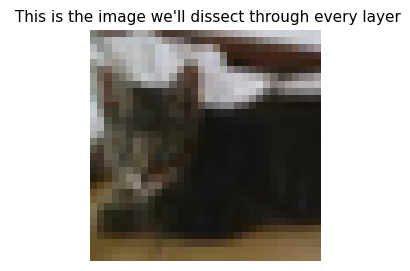

In [19]:
sample_idx = cat_indices[0]
sample_img = x_train[sample_idx]

sample_input = np.expand_dims(sample_img, axis=0)

print(f"Original image shape: {sample_img.shape}")
print(f"Input to model shape: {sample_input.shape}  (batch of 1 image)")
print(f"Label: {'Dog ' if y_train[sample_idx] else 'Cat '}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_img)
plt.title(" This is the image we'll dissect through every layer", fontsize=11)
plt.axis('off')
plt.show()


In [20]:
layer_names = [layer.name for layer in model.layers]
layer_outputs = [model.get_layer(name).output for name in layer_names]

# Ensure the model is built by calling it with sample input
_ = model(sample_input)

# Create a new Functional model for visualization by explicitly using the input of the first layer
visualization_model = keras.Model(inputs=model.layers[0].input, outputs=layer_outputs)

all_layer_outputs = visualization_model.predict(sample_input, verbose=0)

print(f"Number of layers: {len(all_layer_outputs)}\n")
for name, output in zip(layer_names, all_layer_outputs):
    print(f"  {name:25s} → shape: {str(output.shape):20s}")

Number of layers: 7

  conv2d_block1             → shape: (1, 30, 30, 8)      
  maxpool_block1            → shape: (1, 15, 15, 8)      
  conv2d_block2             → shape: (1, 13, 13, 16)     
  maxpool_block2            → shape: (1, 6, 6, 16)       
  flatten                   → shape: (1, 576)            
  dense_hidden              → shape: (1, 32)             
  output_prediction         → shape: (1, 1)              


### Now let's visualize each one!

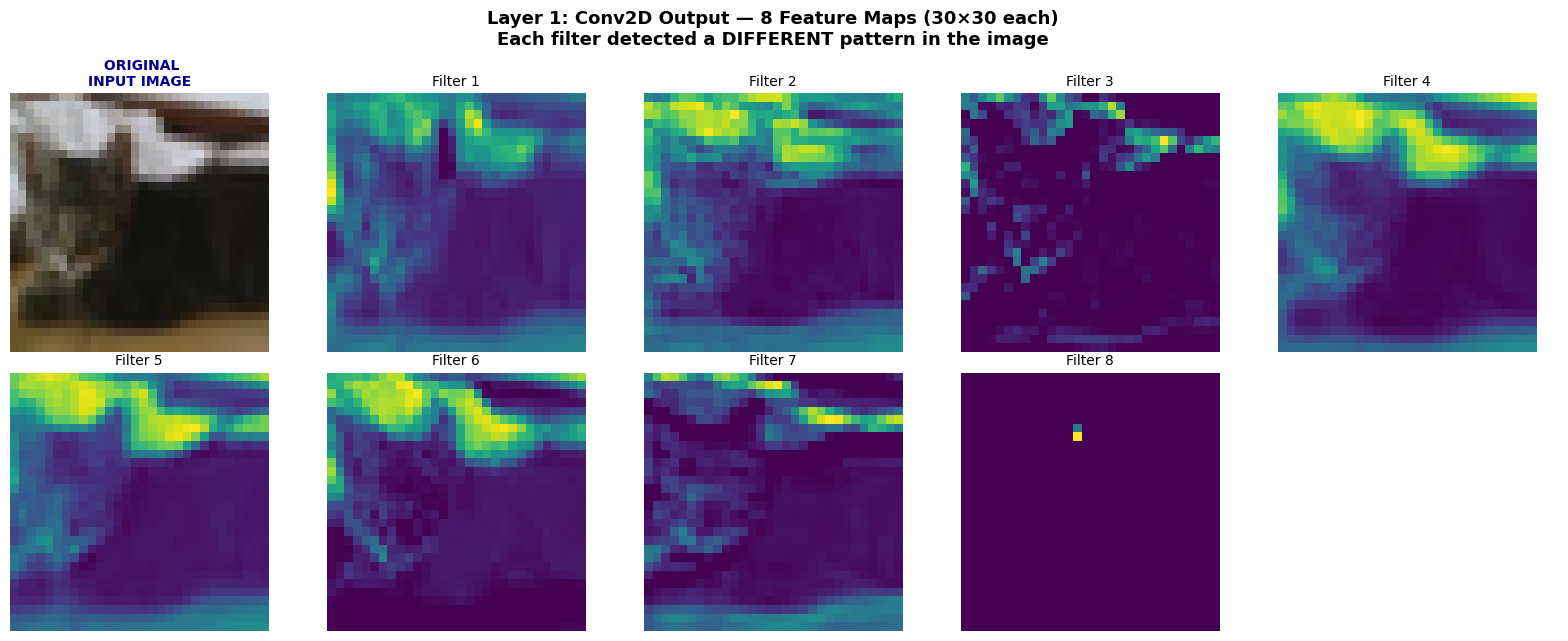

   KEY INSIGHT: Each filter learned to detect something different.
   Bright spots = 'I found this pattern here!'
   Dark spots   = 'Nothing interesting here.'


In [21]:
conv1_output = all_layer_outputs[0]
conv1_maps = conv1_output[0]

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))

axes[0, 0].imshow(sample_img)
axes[0, 0].set_title(" ORIGINAL\nINPUT IMAGE", fontsize=10, fontweight='bold', color='darkblue')
axes[0, 0].axis('off')

plot_positions = [(0,1),(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3)]
for i, (r, c) in enumerate(plot_positions):
    axes[r, c].imshow(conv1_maps[:, :, i], cmap='viridis')
    axes[r, c].set_title(f"Filter {i+1}", fontsize=10)
    axes[r, c].axis('off')

axes[1, 4].axis('off')

fig.suptitle("Layer 1: Conv2D Output — 8 Feature Maps (30×30 each)\n"
             "Each filter detected a DIFFERENT pattern in the image",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("   KEY INSIGHT: Each filter learned to detect something different.")
print("   Bright spots = 'I found this pattern here!'")
print("   Dark spots   = 'Nothing interesting here.'")


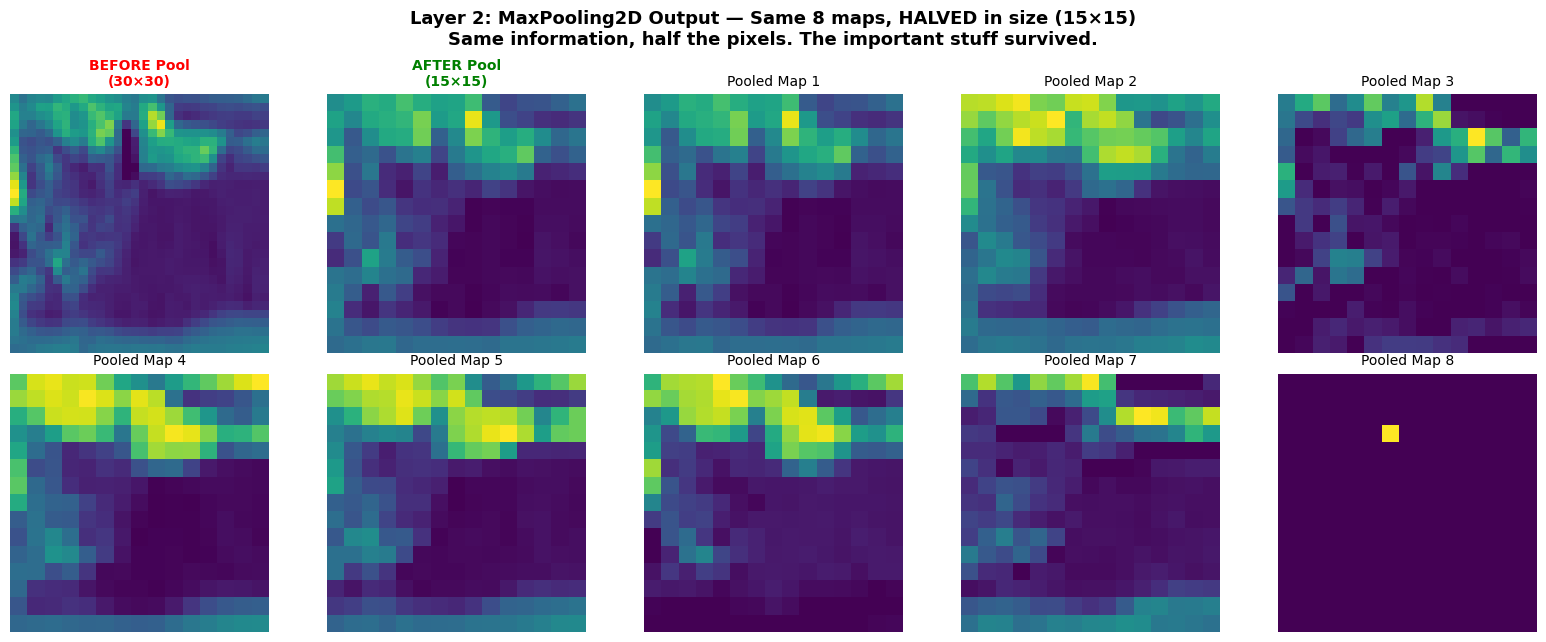

   Size reduction: 30×30 → 15×15
   That's a 75% reduction in data!


In [22]:
pool1_output = all_layer_outputs[1]
pool1_maps = pool1_output[0]

fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))

axes[0, 0].imshow(conv1_maps[:, :, 0], cmap='viridis')
axes[0, 0].set_title("BEFORE Pool\n(30×30)", fontsize=10, fontweight='bold', color='red')
axes[0, 0].axis('off')

axes[0, 1].imshow(pool1_maps[:, :, 0], cmap='viridis')
axes[0, 1].set_title("AFTER Pool\n(15×15)", fontsize=10, fontweight='bold', color='green')
axes[0, 1].axis('off')

plot_positions = [(0,2),(0,3),(0,4),(1,0),(1,1),(1,2),(1,3),(1,4)]
for i, (r, c) in enumerate(plot_positions):
    axes[r, c].imshow(pool1_maps[:, :, i], cmap='viridis')
    axes[r, c].set_title(f"Pooled Map {i+1}", fontsize=10)
    axes[r, c].axis('off')

fig.suptitle("Layer 2: MaxPooling2D Output — Same 8 maps, HALVED in size (15×15)\n"
             "Same information, half the pixels. The important stuff survived.",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"   Size reduction: {conv1_maps.shape[0]}×{conv1_maps.shape[1]} → {pool1_maps.shape[0]}×{pool1_maps.shape[1]}")
print(f"   That's a {(1 - pool1_maps.size/conv1_maps.size)*100:.0f}% reduction in data!")


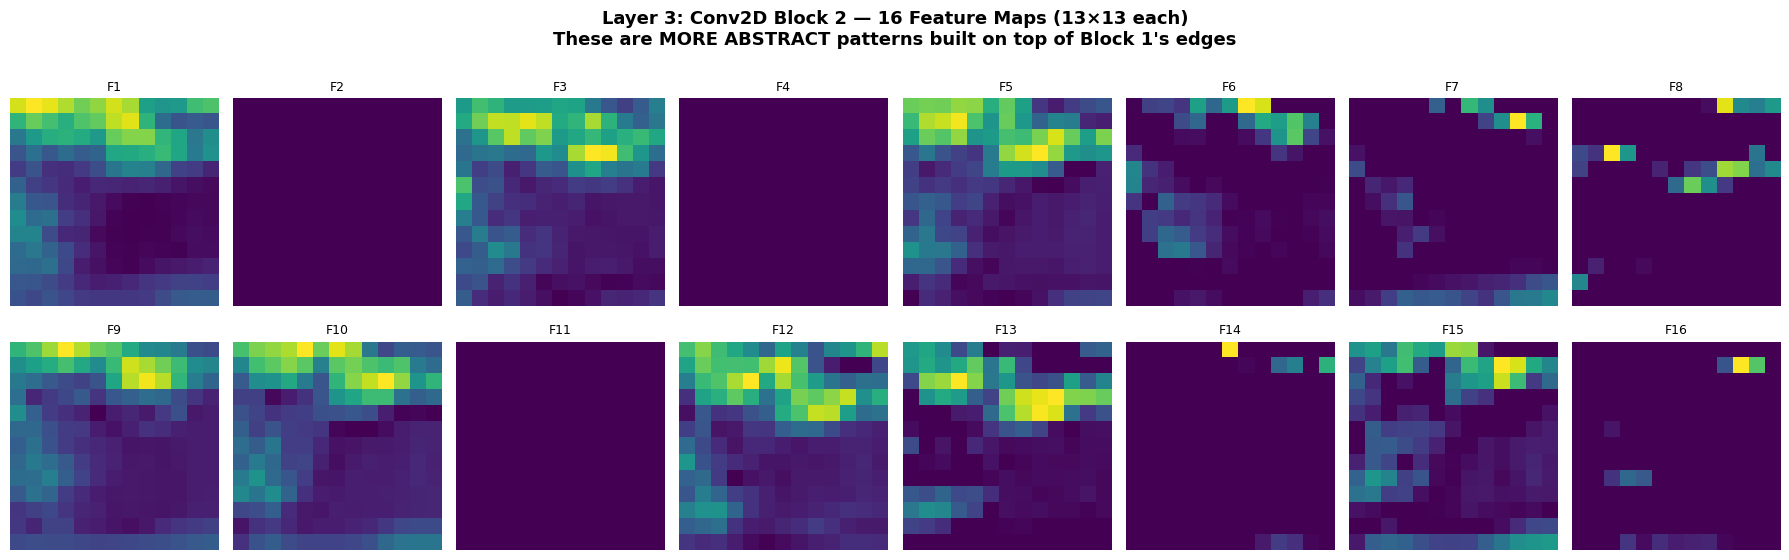

   KEY INSIGHT: Deeper layers detect more complex patterns.
   Block 1 found edges and color blobs.
   Block 2 combines those into textures, shapes, and parts of objects.


In [23]:
conv2_output = all_layer_outputs[2]
conv2_maps = conv2_output[0]

fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for i in range(16):
    r, c = divmod(i, 8)
    axes[r, c].imshow(conv2_maps[:, :, i], cmap='viridis')
    axes[r, c].set_title(f"F{i+1}", fontsize=9)
    axes[r, c].axis('off')

fig.suptitle("Layer 3: Conv2D Block 2 — 16 Feature Maps (13×13 each)\n"
             "These are MORE ABSTRACT patterns built on top of Block 1's edges",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("   KEY INSIGHT: Deeper layers detect more complex patterns.")
print("   Block 1 found edges and color blobs.")
print("   Block 2 combines those into textures, shapes, and parts of objects.")


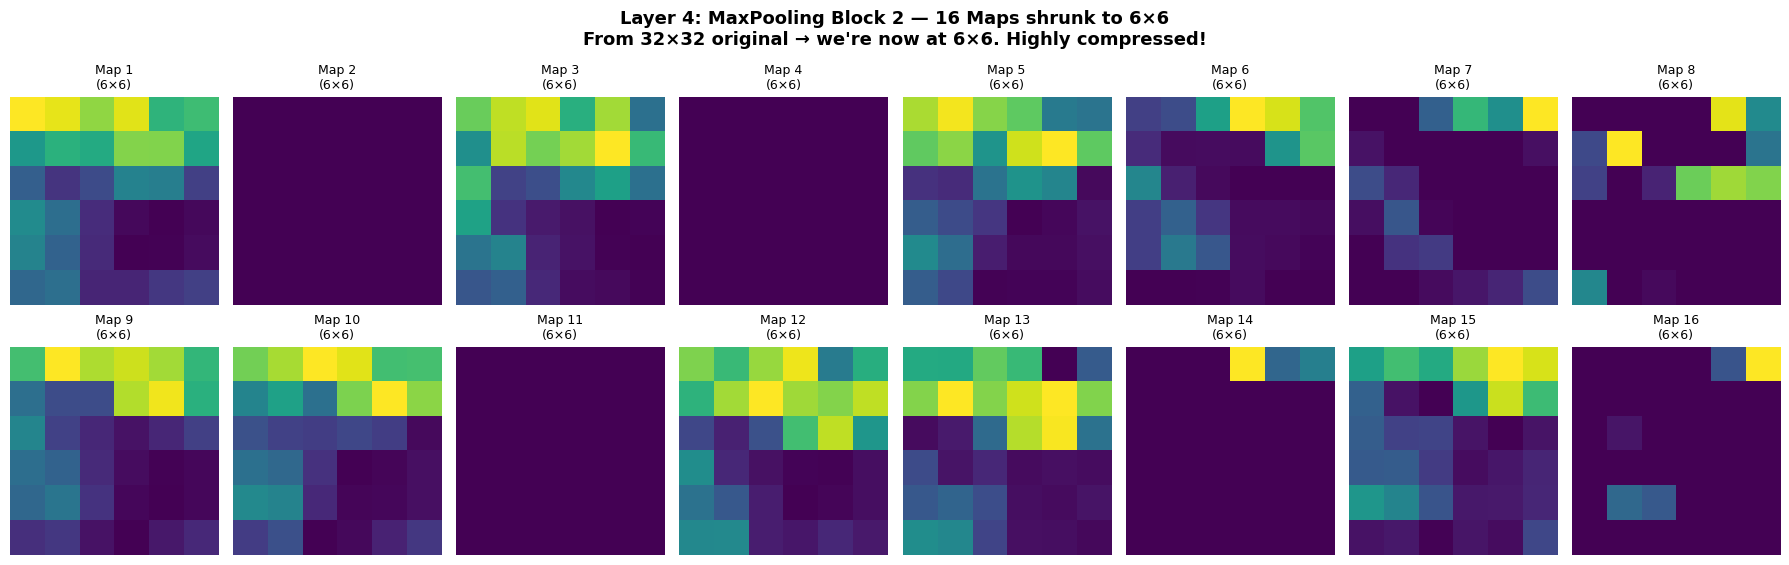

   Journey so far:
   Input image:     32 × 32 × 3  = 3,072 numbers
   After Block 1:   15 × 15 × 8  = 1,800 numbers
   After Block 2:    6 ×  6 × 16 = 576 numbers
   Compression:     3,072 → 576 numbers (81% reduction)


In [24]:
pool2_output = all_layer_outputs[3]
pool2_maps = pool2_output[0]

fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for i in range(16):
    r, c = divmod(i, 8)
    axes[r, c].imshow(pool2_maps[:, :, i], cmap='viridis')
    axes[r, c].set_title(f"Map {i+1}\n(6×6)", fontsize=9)
    axes[r, c].axis('off')

fig.suptitle("Layer 4: MaxPooling Block 2 — 16 Maps shrunk to 6×6\n"
             "From 32×32 original → we're now at 6×6. Highly compressed!",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"   Journey so far:")
print(f"   Input image:     32 × 32 × 3  = {32*32*3:,} numbers")
print(f"   After Block 1:   15 × 15 × 8  = {15*15*8:,} numbers")
print(f"   After Block 2:    6 ×  6 × 16 = {6*6*16:,} numbers")
print(f"   Compression:     {32*32*3:,} → {6*6*16} numbers ({(1-576/(32*32*3))*100:.0f}% reduction)")


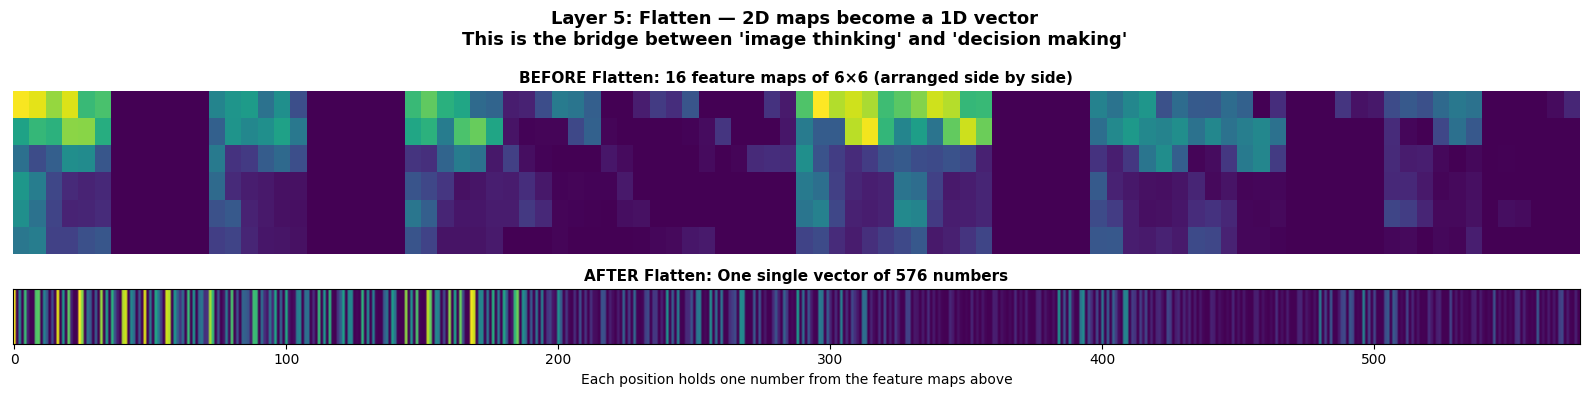

In [25]:
flatten_output = all_layer_outputs[4]

fig, axes = plt.subplots(2, 1, figsize=(16, 4), gridspec_kw={'height_ratios': [3, 1]})

all_maps_row = np.concatenate([pool2_maps[:, :, i] for i in range(16)], axis=1)
axes[0].imshow(all_maps_row, cmap='viridis', aspect='auto')
axes[0].set_title("BEFORE Flatten: 16 feature maps of 6×6 (arranged side by side)", fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(flatten_output.reshape(1, -1), cmap='viridis', aspect='auto')
axes[1].set_title(f"AFTER Flatten: One single vector of {flatten_output.shape[1]} numbers", fontsize=11, fontweight='bold')
axes[1].set_yticks([])
axes[1].set_xlabel("Each position holds one number from the feature maps above")

plt.suptitle("Layer 5: Flatten — 2D maps become a 1D vector\n"
             "This is the bridge between 'image thinking' and 'decision making'",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


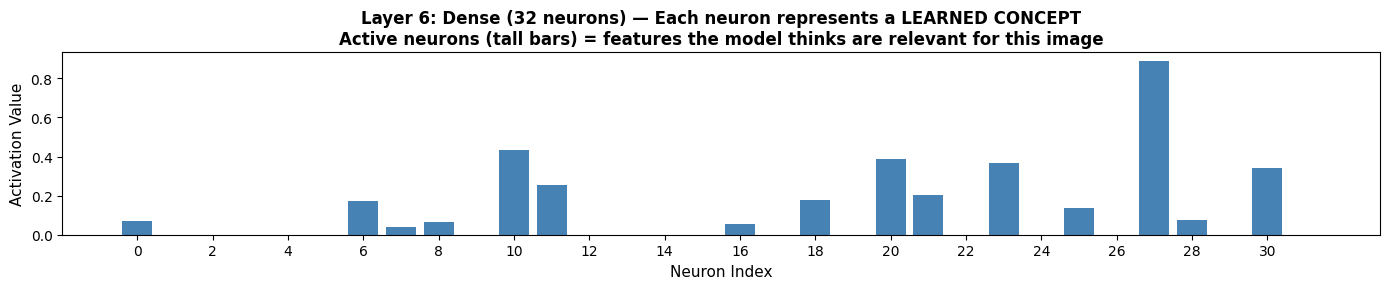

   15 out of 32 neurons are active (value > 0).
   The rest were shut off by ReLU — the model says they're not relevant here.


In [26]:
dense_output = all_layer_outputs[5]

fig, ax = plt.subplots(figsize=(14, 3))

bars = ax.bar(range(32), dense_output[0], color=['steelblue' if v > 0 else 'lightcoral' for v in dense_output[0]])
ax.set_xlabel("Neuron Index", fontsize=11)
ax.set_ylabel("Activation Value", fontsize=11)
ax.set_title("Layer 6: Dense (32 neurons) — Each neuron represents a LEARNED CONCEPT\n"
             "Active neurons (tall bars) = features the model thinks are relevant for this image",
             fontsize=12, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(range(0, 32, 2))

plt.tight_layout()
plt.show()

active_neurons = np.sum(dense_output[0] > 0)
print(f"   {active_neurons} out of 32 neurons are active (value > 0).")
print(f"   The rest were shut off by ReLU — the model says they're not relevant here.")


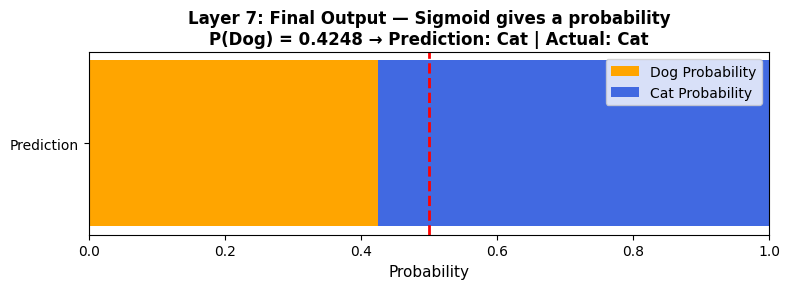

   The sigmoid function squashes the output to [0, 1].
   > 0.5 → Dog
   < 0.5 → Cat
   Model says: 0.4248 → Cat

   The model hasn't been trained yet! This is a RANDOM guess.
   Let's train it and see how it improves.


In [27]:
final_output = all_layer_outputs[6]
probability = final_output[0][0]

fig, ax = plt.subplots(figsize=(8, 3))

ax.barh(['Prediction'], [probability], color='orange', height=0.4, label='Dog Probability')
ax.barh(['Prediction'], [1 - probability], left=[probability], color='royalblue', height=0.4, label='Cat Probability')
ax.set_xlim(0, 1)
ax.set_xlabel('Probability', fontsize=11)
ax.legend(loc='upper right')
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')

prediction = "Dog" if probability > 0.5 else "Cat"
actual = "Dog" if y_train[sample_idx] == 1 else "Cat"

ax.set_title(f"Layer 7: Final Output — Sigmoid gives a probability\n"
             f"P(Dog) = {probability:.4f} → Prediction: {prediction} | Actual: {actual}",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"   The sigmoid function squashes the output to [0, 1].")
print(f"   > 0.5 → Dog")
print(f"   < 0.5 → Cat")
print(f"   Model says: {probability:.4f} → {prediction}")
print(f"\n   The model hasn't been trained yet! This is a RANDOM guess.")
print(f"   Let's train it and see how it improves.")


## Section 8: The Complete CNN

Let's see the **entire transformation** from raw image to final prediction in one view:


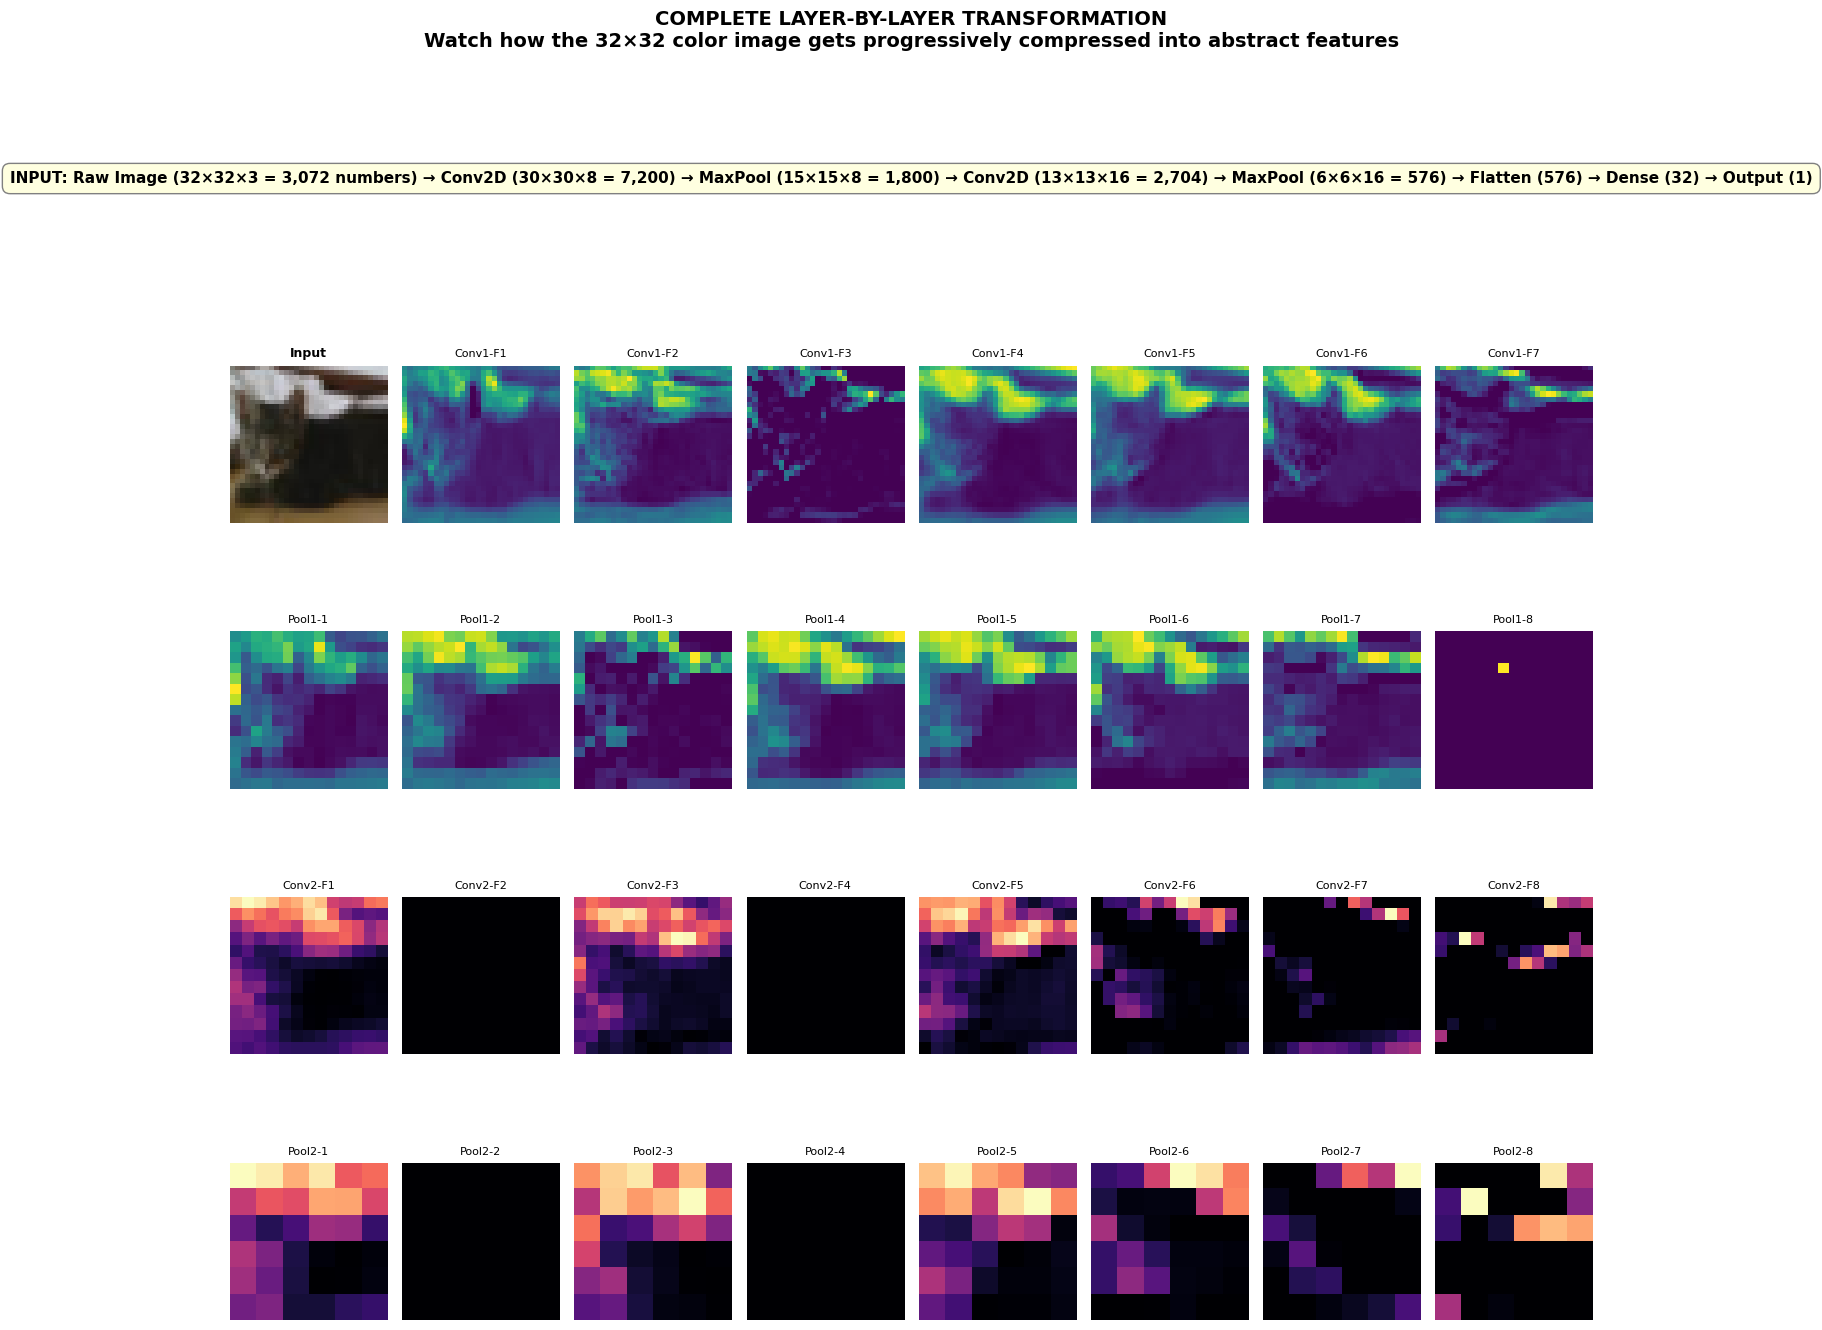

In [28]:
fig = plt.figure(figsize=(18, 14))

ax = fig.add_subplot(5, 1, 1)
ax.text(0.5, 0.5,
    f"INPUT: Raw Image (32×32×3 = {32*32*3:,} numbers) → "
    f"Conv2D (30×30×8 = {30*30*8:,}) → "
    f"MaxPool (15×15×8 = {15*15*8:,}) → "
    f"Conv2D (13×13×16 = {13*13*16:,}) → "
    f"MaxPool (6×6×16 = {6*6*16}) → "
    f"Flatten ({576}) → "
    f"Dense ({32}) → "
    f"Output ({1})",
    ha='center', va='center', fontsize=11, fontweight='bold',
    transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", edgecolor="gray"))
ax.axis('off')

ax = fig.add_subplot(5, 8, 9)
ax.imshow(sample_img)
ax.set_title("Input", fontsize=9, fontweight='bold')
ax.axis('off')

for i in range(7):
    ax = fig.add_subplot(5, 8, 10+i)
    ax.imshow(conv1_maps[:, :, i], cmap='viridis')
    ax.set_title(f"Conv1-F{i+1}", fontsize=8)
    ax.axis('off')

for i in range(8):
    ax = fig.add_subplot(5, 8, 17+i)
    ax.imshow(pool1_maps[:, :, i], cmap='viridis')
    ax.set_title(f"Pool1-{i+1}", fontsize=8)
    ax.axis('off')

for i in range(8):
    ax = fig.add_subplot(5, 8, 25+i)
    ax.imshow(conv2_maps[:, :, i], cmap='magma')
    ax.set_title(f"Conv2-F{i+1}", fontsize=8)
    ax.axis('off')

for i in range(8):
    ax = fig.add_subplot(5, 8, 33+i)
    ax.imshow(pool2_maps[:, :, i], cmap='magma')
    ax.set_title(f"Pool2-{i+1}", fontsize=8)
    ax.axis('off')

fig.suptitle("COMPLETE LAYER-BY-LAYER TRANSFORMATION\n"
             "Watch how the 32×32 color image gets progressively compressed into abstract features",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##  Section 9: Train the Model

Now we **train** the model. This means:
1. Show the model thousands of cat/dog images
2. It makes predictions
3. Calculate how wrong it was (the **loss**)
4. Adjust the filter values slightly to be less wrong
5. Repeat for many **epochs** (full passes through the data)

```
   Epoch 1:  Model is guessing randomly     → ~50% accuracy (coin flip)
   Epoch 5:  Model is learning basic edges   → ~55-60% accuracy
   Epoch 10: Model recognizes cat/dog shapes → ~65-70% accuracy
   Epoch 20: Model is getting good           → ~70-75% accuracy
```


In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(x_train, y_train,epochs=15,batch_size=64,validation_split=0.2,verbose=1)

print("\nTraining complete!")


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.5765 - loss: 0.6724 - val_accuracy: 0.5995 - val_loss: 0.6601
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6281 - loss: 0.6419 - val_accuracy: 0.6480 - val_loss: 0.6335
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.6600 - loss: 0.6117 - val_accuracy: 0.6710 - val_loss: 0.6092
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.6835 - loss: 0.5906 - val_accuracy: 0.6720 - val_loss: 0.6013
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7003 - loss: 0.5782 - val_accuracy: 0.6825 - val_loss: 0.5925
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7100 - loss: 0.5609 - val_accuracy: 0.6975 - val_loss: 0.5805
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.7214 - loss: 0.5459 - val_accuracy: 0.6860 - val_loss: 0.5968
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.7318 - loss: 0.5356 - val_accu

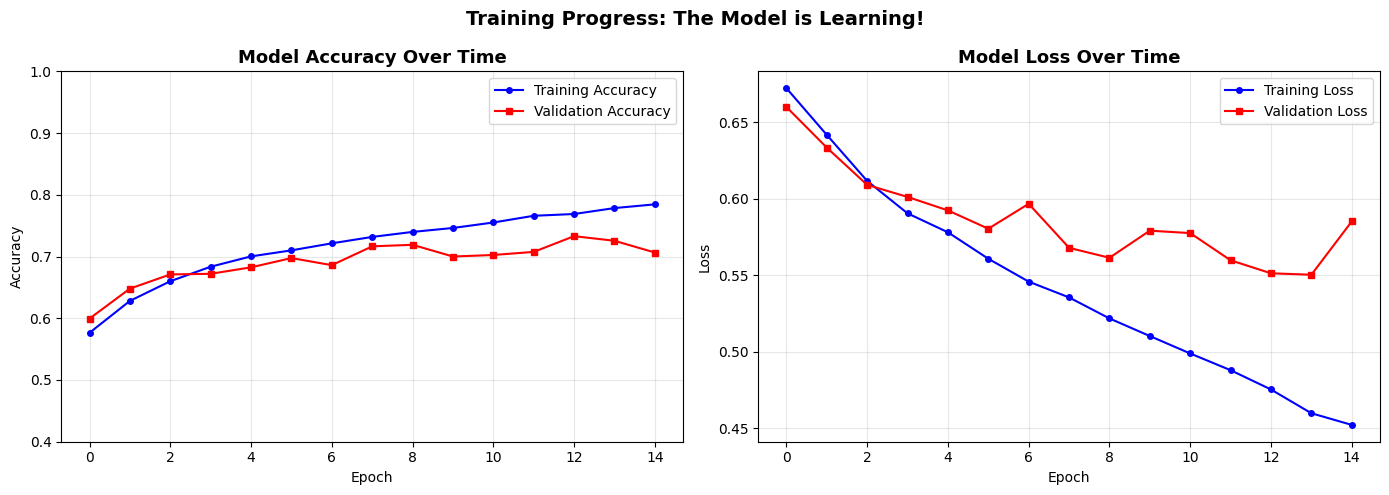

Final Training Accuracy:   78.5%
Final Validation Accuracy: 70.6%


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], 'b-o', label='Training Accuracy', markersize=4)
axes[0].plot(history.history['val_accuracy'], 'r-s', label='Validation Accuracy', markersize=4)
axes[0].set_title('Model Accuracy Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.4, 1.0])

axes[1].plot(history.history['loss'], 'b-o', label='Training Loss', markersize=4)
axes[1].plot(history.history['val_loss'], 'r-s', label='Validation Loss', markersize=4)
axes[1].set_title('Model Loss Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Progress: The Model is Learning!", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100
print(f"Final Training Accuracy:   {final_train_acc:.1f}%")
print(f"Final Validation Accuracy: {final_val_acc:.1f}%")


## Section 10: See What the TRAINED Model Sees

Now let's repeat our layer visualization — but this time the model has **learned** real patterns!

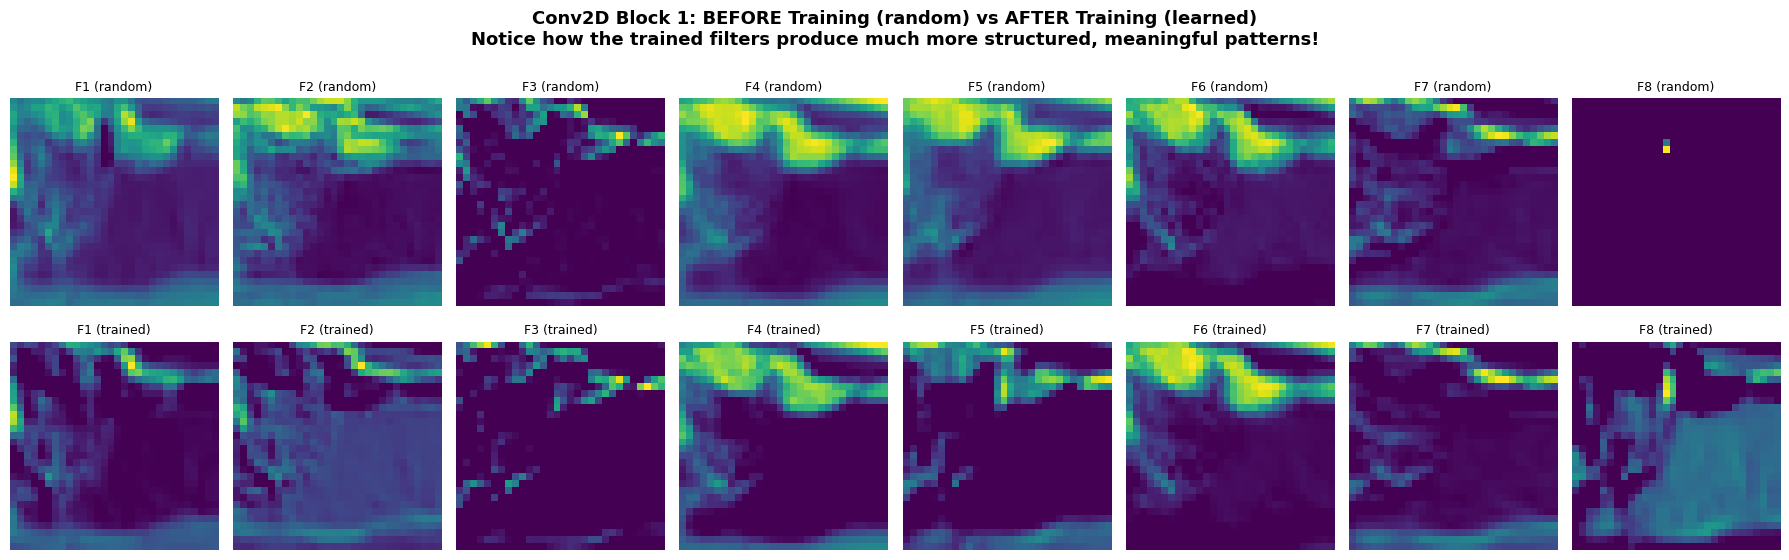

In [32]:
visualization_model_trained = keras.Model(inputs=model.layers[0].input, outputs=layer_outputs)
all_outputs_trained = visualization_model_trained.predict(sample_input, verbose=0)

conv1_trained = all_outputs_trained[0][0]
conv2_trained = all_outputs_trained[2][0]
dense_trained = all_outputs_trained[5][0]

fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for i in range(8):
    axes[0, i].imshow(conv1_maps[:, :, i], cmap='viridis')
    axes[0, i].set_title(f"F{i+1} (random)", fontsize=9)
    axes[0, i].axis('off')

for i in range(8):
    axes[1, i].imshow(conv1_trained[:, :, i], cmap='viridis')
    axes[1, i].set_title(f"F{i+1} (trained)", fontsize=9)
    axes[1, i].axis('off')

fig.suptitle("Conv2D Block 1: BEFORE Training (random) vs AFTER Training (learned)\n"
             "Notice how the trained filters produce much more structured, meaningful patterns!",
             fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel("UNTRAINED", fontsize=11, fontweight='bold', color='red')
axes[1, 0].set_ylabel("TRAINED", fontsize=11, fontweight='bold', color='green')
plt.tight_layout()
plt.show()

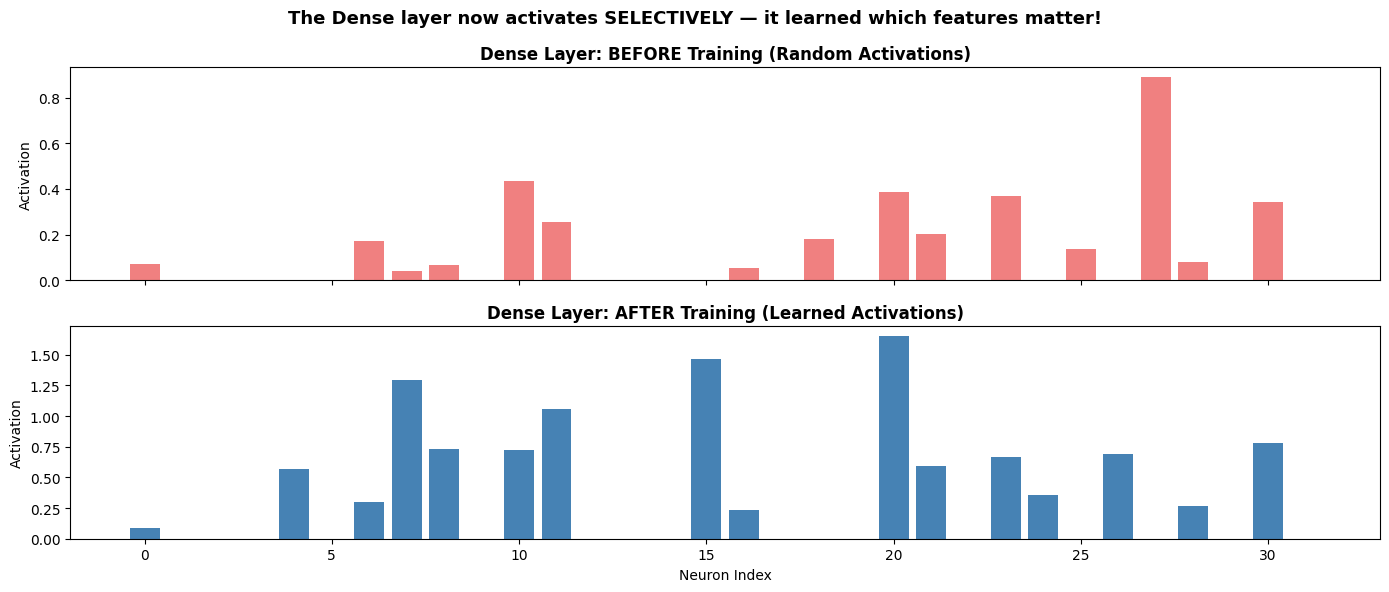

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].bar(range(32), dense_output[0], color='lightcoral')
axes[0].set_title("Dense Layer: BEFORE Training (Random Activations)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Activation")
axes[0].axhline(y=0, color='black', linewidth=0.5)

axes[1].bar(range(32), dense_trained, color='steelblue')
axes[1].set_title("Dense Layer: AFTER Training (Learned Activations)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Activation")
axes[1].set_xlabel("Neuron Index")
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.suptitle("The Dense layer now activates SELECTIVELY — it learned which features matter!",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


##  Section 11: Evaluate — Does the Model Actually Work?

Let's test it on images **it has never seen before** (the test set).


In [34]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print(f" Test Accuracy: {test_accuracy*100:.1f}%")
print(f" Test Loss:     {test_loss:.4f}")
print(f"\nFor reference:")
print(f"  50% = random guessing (coin flip)")
print(f"  {test_accuracy*100:.1f}% = our simple CNN with only ~6K parameters")
print(f"\n  (State-of-the-art models get 95%+ on this task,")
print(f"   but they use millions of parameters and much larger images)")


 Test Accuracy: 72.3%
 Test Loss:     0.5633

For reference:
  50% = random guessing (coin flip)
  72.3% = our simple CNN with only ~6K parameters

  (State-of-the-art models get 95%+ on this task,
   but they use millions of parameters and much larger images)


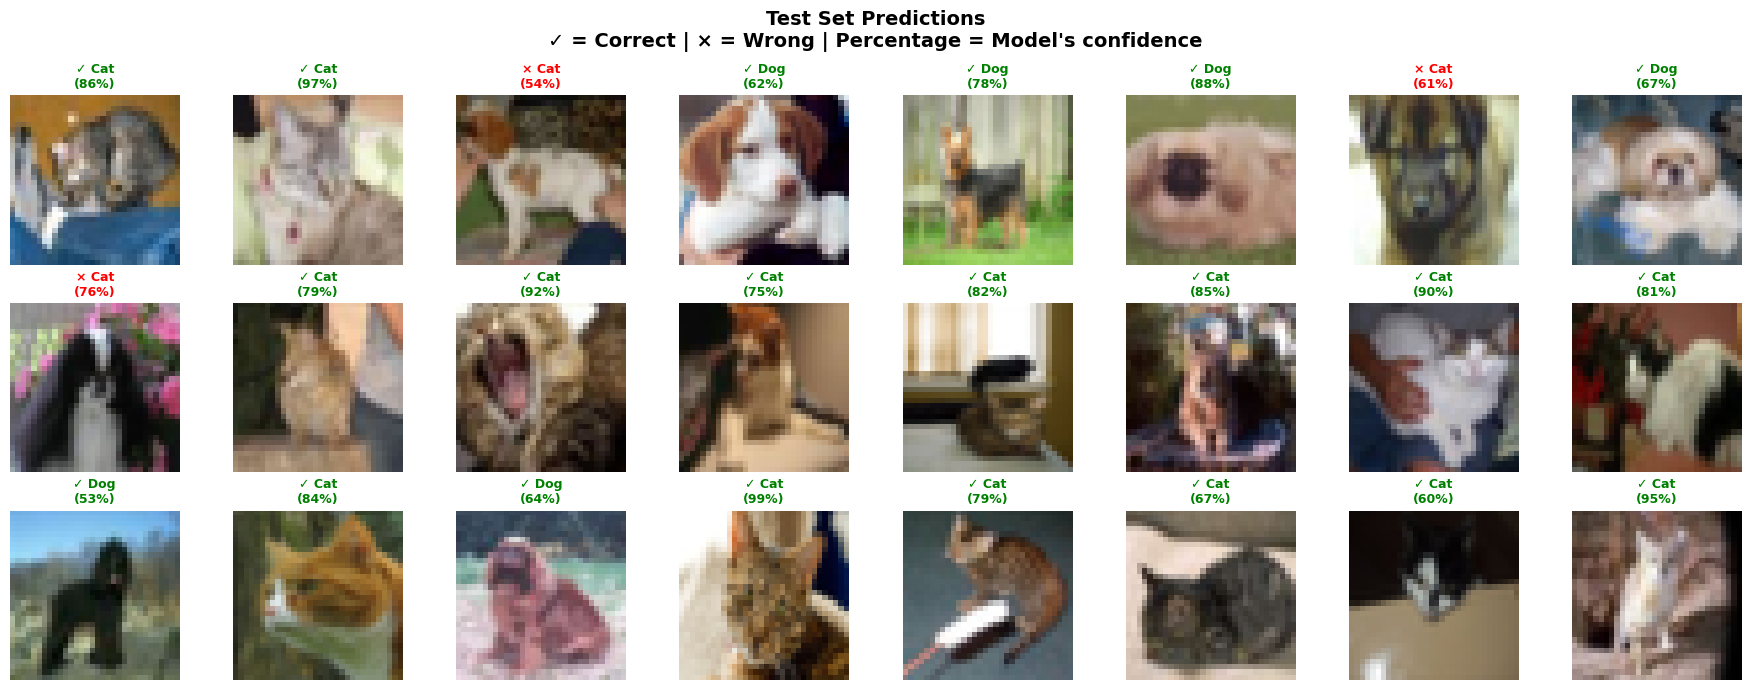

Correct: 21/24 on this sample


In [35]:
predictions = model.predict(x_test[:24], verbose=0).flatten()

fig, axes = plt.subplots(3, 8, figsize=(18, 7))

for i in range(24):
    r, c = divmod(i, 8)
    axes[r, c].imshow(x_test[i])

    pred_label = "Dog" if predictions[i] > 0.5 else "Cat"
    true_label = "Dog" if y_test[i] == 1 else "Cat"
    confidence = predictions[i] if predictions[i] > 0.5 else 1 - predictions[i]

    is_correct = pred_label == true_label
    color = 'green' if is_correct else 'red'
    symbol = '✓' if is_correct else '×'

    axes[r, c].set_title(f"{symbol} {pred_label}\n({confidence:.0%})",
                          fontsize=9, color=color, fontweight='bold')
    axes[r, c].axis('off')

fig.suptitle("Test Set Predictions\n"
             "✓ = Correct | × = Wrong | Percentage = Model's confidence",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

correct = sum((predictions > 0.5) == y_test[:24])
print(f"Correct: {correct}/24 on this sample")


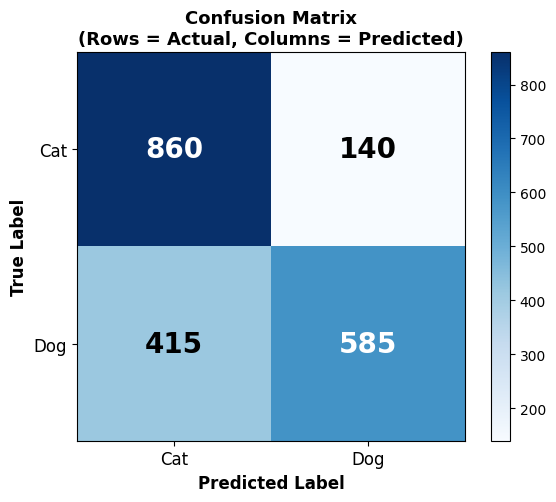

              precision    recall  f1-score   support

         Cat       0.67      0.86      0.76      1000
         Dog       0.81      0.58      0.68      1000

    accuracy                           0.72      2000
   macro avg       0.74      0.72      0.72      2000
weighted avg       0.74      0.72      0.72      2000



In [36]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(x_test, verbose=0).flatten() > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

labels = ['Cat', 'Dog']
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, f"{cm[i,j]}", ha='center', va='center',
                fontsize=20, fontweight='bold', color=text_color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix\n(Rows = Actual, Columns = Predicted)', fontsize=13, fontweight='bold')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Cat', 'Dog']))


##  Section 12: Bonus — What Do the Learned Filters Look Like?

The Conv2D filters are just tiny 3×3 grids of numbers. Let's see what patterns they learned.


Filter weights shape: (3, 3, 3, 8)
Meaning: 8 filters, each is 3×3 pixels, with 3 color channels



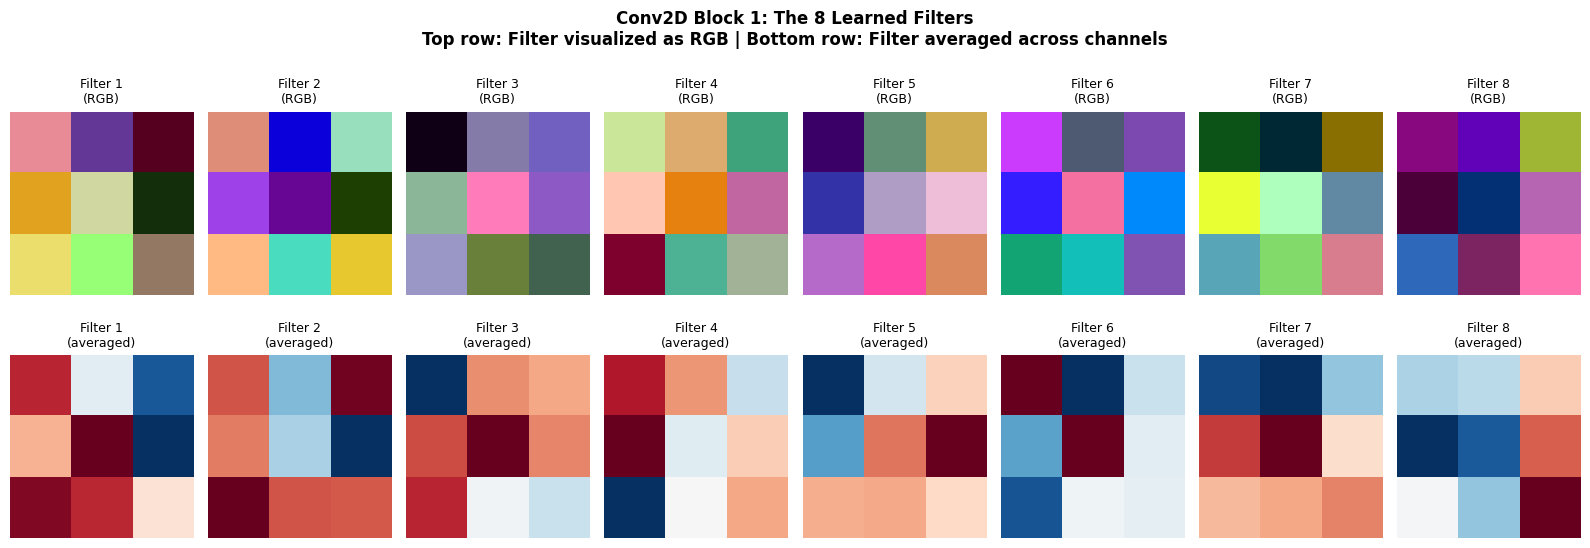

   These tiny 3×3 grids are what the model learned to look for.
   Light/dark patterns = edge detectors in various directions.
   Color patterns = color-specific feature detectors.


In [37]:
filters_block1 = model.layers[0].get_weights()[0]

print(f"Filter weights shape: {filters_block1.shape}")
print(f"Meaning: 8 filters, each is 3×3 pixels, with 3 color channels\n")

fig, axes = plt.subplots(2, 8, figsize=(16, 6))
fig.suptitle("Conv2D Block 1: The 8 Learned Filters\n"
             "Top row: Filter visualized as RGB | Bottom row: Filter averaged across channels",
             fontsize=12, fontweight='bold')

for i in range(8):
    f = filters_block1[:, :, :, i]
    f_normalized = (f - f.min()) / (f.max() - f.min() + 1e-8)

    axes[0, i].imshow(f_normalized, interpolation='nearest')
    axes[0, i].set_title(f"Filter {i+1}\n(RGB)", fontsize=9)
    axes[0, i].axis('off')

    f_avg = f.mean(axis=2)
    axes[1, i].imshow(f_avg, cmap='RdBu_r', interpolation='nearest')
    axes[1, i].set_title(f"Filter {i+1}\n(averaged)", fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("   These tiny 3×3 grids are what the model learned to look for.")
print("   Light/dark patterns = edge detectors in various directions.")
print("   Color patterns = color-specific feature detectors.")


## Section 13: Full Recap — What We Learned

---

### The CNN Pipeline:

| Layer | What It Does | Input Shape | Output Shape | Analogy |
|-------|-------------|-------------|--------------|---------|
| **Input** | Raw pixel data | — | 32×32×3 | A photograph |
| **Conv2D (8 filters)** | Scans for local patterns (edges, colors) | 32×32×3 | 30×30×8 | 8 different colored glasses, each highlighting different features |
| **ReLU** | Kills negative values (noise removal) | 30×30×8 | 30×30×8 | A bouncer: "No negativity allowed!" |
| **MaxPool2D** | Shrinks by keeping max values | 30×30×8 | 15×15×8 | A summary: keep the highlights, drop the filler |
| **Conv2D (16 filters)** | Finds complex patterns from simple ones | 15×15×8 | 13×13×16 | Combining edges into shapes, textures, parts |
| **ReLU** | Same noise cleanup | 13×13×16 | 13×13×16 | Same bouncer, deeper in the club |
| **MaxPool2D** | Shrinks again | 13×13×16 | 6×6×16 | Even shorter summary |
| **Flatten** | Unrolls 2D→1D | 6×6×16 | 576 | Rolling out a rug into a rope |
| **Dense (32)** | Combines all features | 576 | 32 | A committee of 32 experts voting |
| **Dense (1, sigmoid)** | Final probability | 32 | 1 | Final verdict: Cat or Dog? |

---

### Key Takeaways:

1. **CNNs are feature extractors** — they automatically learn what patterns matter
2. **Early layers** learn simple things (edges, colors, textures)
3. **Later layers** learn complex things (shapes, parts of faces, fur patterns)
4. **Pooling** compresses information while keeping what matters
5. **Dense layers** make the final decision based on all extracted features
6. **Training** adjusts all the filter values to minimize prediction errors

---